In [2]:
# ============================================================
# Cell 1: Environment Setup
# ============================================================
import torch

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info(0)
    print(f"GPU Memory      : {total / 1e9:.1f} GB  (free: {free / 1e9:.1f} GB)")

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
WORK_DIR = "/content/drive/MyDrive/Colab Notebooks/RAMC NN Training"
os.chdir(WORK_DIR)
print(f"\nWorking directory: {os.getcwd()}")
print("\nFiles in directory:")
for f in sorted(os.listdir('.')):
    size_mb = os.path.getsize(f) / 1e6 if os.path.isfile(f) else 0
    print(f"  {f:<45s} {size_mb:>8.2f} MB" if os.path.isfile(f) else f"  {f}/")

# ── A1/A2 ablation labels detection ───────────────────────────
NPZ_PATH = "RAMC_perturbed_labels_K4.npz"
if os.path.exists(NPZ_PATH):
    size_mb = os.path.getsize(NPZ_PATH) / 1e6
    print(f"\nAblation labels: {NPZ_PATH}  ({size_mb:.1f} MB) — "
          f"A1 (PertOnly) and A2 (MeanCost) will train.")
else:
    raise FileNotFoundError(
        f"Missing {NPZ_PATH}. Upload it from local before running Cell 3, "
        f"or remove this assertion to train only A0 (Fidelity), Raw MSE, and RAMC."
    )

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : NVIDIA L4
GPU Memory      : 23.7 GB  (free: 23.5 GB)
Mounted at /content/drive

Working directory: /content/drive/MyDrive/Colab Notebooks/RAMC NN Training

Files in directory:
  Decompose_evaluation.py                           0.04 MB
  Fig4_decomposition_single_IEEE.py                 0.00 MB
  Fig5_rollout_2panel_IEEE.py                       0.01 MB
  RAMC_Training_Run.ipynb                           1.50 MB
  RAMC_perturbed_labels_K4.npz                     56.32 MB
  RAMC_training_data_N3.csv                       120.26 MB
  __pycache__/
  generate_perturbed_labels.py                      0.01 MB
  hyperparameter_sensitivity.py                     0.01 MB
  main_experiment.py                                0.04 MB
  make_fig4_2x2_from_decomposed_csv.py              0.00 MB
  make_fig6_rollout_2panel.py                       0.00 MB
  openloop_rollout_eval.py                          0.02 MB
  pooled_ecdf_ana

In [2]:
# ── Quick smoke test of the new loss paths on this environment ──
import runpy
runpy.run_path("test_ablation_paths.py", run_name="__main__")

Running ablation-path smoke tests...

  PASS: mean operator dispatcher
  PASS: mean loss path (fid=5032.2422, risk=4290.8955, total=5036.5332)
  PASS: pert_only raises ValueError on missing labels
  PASS: pert_only matches manual MSE (risk_loss=416.170227)
  PASS: default CVaR path unchanged (total=2290.7646)
  PASS: lambda=0 early exit works for both loss modes

All tests passed.


{'__name__': '__main__',
 '__doc__': "\ntest_ablation_paths.py\n\nSmoke tests for the new causal-ablation loss paths in ramc_losses.py.\nVerifies that the diffs are correctly applied before any wall-clock\ntraining run is started. Should finish in seconds on CPU.\n\nCovers:\n  - The new `mean` operator in risk_from_cost_samples.\n  - The new loss_mode='pert_only' branch in calculate_ramc_loss,\n    including the missing-labels error path and the manual-MSE check.\n  - Regression: the default loss_mode='ramc' path with CVaR still works.\n  - The early-exit at lambda_risk=0 still works for both modes.\n\nRun from the directory containing ramc_losses.py:\n    python test_ablation_paths.py\n",
 '__package__': '',
 '__loader__': None,
 '__spec__': None,
 '__file__': 'test_ablation_paths.py',
 '__cached__': None,
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifier

In [3]:
# ============================================================
# Cell 2: Pre-flight checks
#   - Dataset integrity (columns, ranges)
#   - Solar column name cross-check against RCModelDataset
#   - Module imports
#   - Rollout config summary
# ============================================================
import pandas as pd
import numpy as np

CSV_PATH = "RAMC_training_data_N3.csv"
assert os.path.exists(CSV_PATH), f"Dataset not found: {CSV_PATH}"

# ── Column presence ──────────────────────────────────────────
df_head = pd.read_csv(CSV_PATH, nrows=5)
print(f"Dataset columns ({len(df_head.columns)}):")
print(df_head.columns.tolist())

required = [
    'T_air_k', 'T_env_k', 'T_int_k', 'T_rad1_k', 'T_rad2_k', 'T_ret_k',
    'T_supply_k', 'mdot_k', 'T_out_k', 'Q_internal_k',
    'T_air_k1', 'T_env_k1', 'T_int_k1', 'T_rad1_k1', 'T_rad2_k1', 'T_ret_k1',
    'Tmin', 'Tmax', 'Timestamp',
]

# Auto-detect solar column name
solar_col = next(
    (c for c in ['Q_solar_trans_k', 'Q_solar_k', 'I_solar_k'] if c in df_head.columns),
    None,
)
print(f"\nSolar column detected: {solar_col}")

missing = [c for c in required if c not in df_head.columns]
if missing:
    print(f"\nMissing columns: {missing}")
else:
    print("All required columns present")

# ── Data ranges ──────────────────────────────────────────────
usecols = ['Q_internal_k', 'T_out_k', 'Tmin', 'Tmax']
if solar_col:
    usecols.append(solar_col)
df_ranges = pd.read_csv(CSV_PATH, usecols=usecols)

print(f"\nQ_internal_k : [{df_ranges['Q_internal_k'].min():.0f}, {df_ranges['Q_internal_k'].max():.0f}] W")
if solar_col:
    print(f"{solar_col:<13s}: [{df_ranges[solar_col].min():.0f}, {df_ranges[solar_col].max():.0f}] W")
print(f"T_out_k      : [{df_ranges['T_out_k'].min():.1f}, {df_ranges['T_out_k'].max():.1f}] °C")
print(f"Tmin         : [{df_ranges['Tmin'].min():.1f}, {df_ranges['Tmin'].max():.1f}] °C  (ignored during training)")
print(f"Tmax         : [{df_ranges['Tmax'].min():.1f}, {df_ranges['Tmax'].max():.1f}] °C  (ignored during training)")
print("NOTE: comfort_bounds=(20.0, 22.0) is used uniformly (ignore_dataset_bounds=True)")

# ── Solar column cross-check vs RCModelDataset ───────────────
from thermal_dynamics_net import (
    RCModelDataset,
    ThermalDynamicsNet,
    create_dataloaders,
    build_clamp_bounds_from_dataset,
    RolloutSequenceSampler,
)
from trainers import TrainingManager, RAMCTrainer, MSETrainer
from ramc_losses import (
    calculate_ramc_loss,
    evaluate_on_loader,
    compute_rollout_fidelity_loss,
)

expected_solar = RCModelDataset.DISTURBANCE_COLS[1]   # index 1 = solar column
print(f"\nRCModelDataset expects solar column : '{expected_solar}'")
print(f"CSV solar column detected           : '{solar_col}'")

if expected_solar != solar_col:
    print(
        f"\nMISMATCH — update DISTURBANCE_COLS in thermal_dynamics_net.py:\n"
        f"   Change '{expected_solar}' -> '{solar_col}'\n"
        f"   Then re-upload the file and rerun this cell."
    )
    raise SystemExit("Aborting: solar column mismatch.")
else:
    print("Column names match")

print("\nAll imports successful")

# ── Rollout config summary ────────────────────────────────────
from main_experiment import LOSS_CONFIG, LAMBDA_VALUES, EXPERIMENT_MODE

alpha_ro = LOSS_CONFIG.get("alpha_rollout", 0.0)
H_r      = LOSS_CONFIG.get("rollout_horizon", 6)
B_r      = LOSS_CONFIG.get("rollout_batch_size", 64)

print(f"\n{'─'*55}")
print(f"Experiment mode      : {EXPERIMENT_MODE}")
print(f"Lambda grid          : {LAMBDA_VALUES}")
print(f"Rollout fidelity (α) : {alpha_ro}  ({'ENABLED' if alpha_ro > 0 else 'disabled'})")
if alpha_ro > 0:
    print(f"  Rollout horizon H_r: {H_r} steps  ({H_r * 10} min)")
    print(f"  Rollout batch B_r  : {B_r} sequences")
    print(f"  Checkpoint suffix  : _rollout_a{alpha_ro}")
print(f"{'─'*55}")


Dataset columns (29):
['Timestamp', 'episode_id', 'step_in_episode', 'policy', 'Occupied', 'Tmin', 'Tmax', 'T_air_k', 'T_env_k', 'T_int_k', 'T_rad1_k', 'T_rad2_k', 'T_ret_k', 'T_supply_k', 'mdot_k', 'T_out_k', 'Q_internal_k', 'I_solar_k', 'Q_solar_trans_k', 'T_supply_idf_base_k', 'Q_solar_air_k', 'Q_solar_int_k', 'Q_heat_proxy_k', 'T_air_k1', 'T_env_k1', 'T_int_k1', 'T_rad1_k1', 'T_rad2_k1', 'T_ret_k1']

Solar column detected: Q_solar_trans_k
All required columns present

Q_internal_k : [3508, 79511] W
Q_solar_trans_k: [0, 27311] W
T_out_k      : [-26.0, 8.0] °C
Tmin         : [15.1, 21.5] °C  (ignored during training)
Tmax         : [16.1, 22.5] °C  (ignored during training)
NOTE: comfort_bounds=(20.0, 22.0) is used uniformly (ignore_dataset_bounds=True)

RCModelDataset expects solar column : 'Q_solar_trans_k'
CSV solar column detected           : 'Q_solar_trans_k'
Column names match

All imports successful

───────────────────────────────────────────────────────
Experiment mode      

Starting main_experiment.py …
TF32 enabled
RAMC TRAINING EXPERIMENT - MODE: FULL | RISK: cvar
Experiment Date : 2026-05-18 18:28:22
Results Dir     : results/RAMC_FULL_cvar_20260518_182822
Device          : cuda
Risk Operator   : cvar
Training K      : 32
GPU             : NVIDIA L4

IMPROVEMENTS ENABLED:
  P1:  Baseline hygiene (Raw MSE vs Fidelity naming)
  P2:  Configurable clamp bounds from TRAIN data quantiles
  P3:  Open-loop multi-step rollout evaluation (TEST only)
  P4:  Energy proxy (Q) error metrics
  P5A: Antithetic sampling for variance reduction
  P7:  Episode segmentation for valid rollouts
  P9:  CVaR RU works under torch.no_grad()
  P10: Decomposed risk (comfort vs energy)
  P11: Occupancy-conditional evaluation
  FIX: Skip risk computation when lambda=0
  FIX: Test-only rollout evaluation
  FIX: Corrected disturbance bounds (Q_solar: 40kW, Q_internal: 1kW)
  NEW: CSV export for Tables IV and V
  NEW: Methods summary generator for paper
  NEW: Rollout-aware fidelity (a

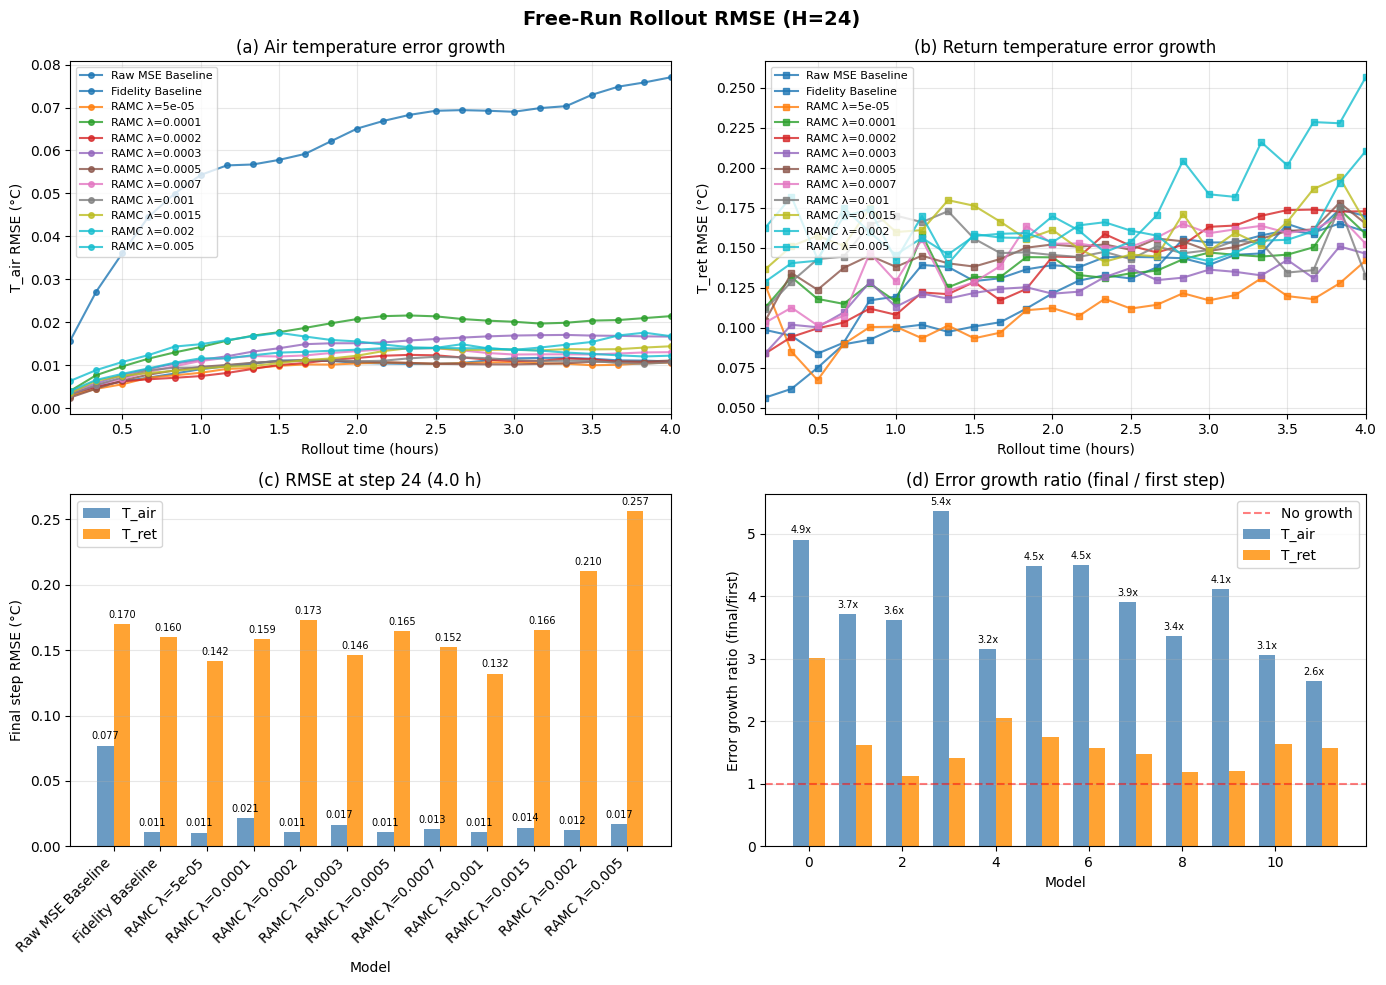


Rollout evaluation completed (test set only).

STEP 4: T_AIR BIAS / FIDELITY SANITY CHECK
----------------------------------------------------------------------
Raw MSE Baseline       | T_air RMSE=0.0166 | Bias=-0.0004 [OK] | Q_rmse=551.4 W
Fidelity Baseline      | T_air RMSE=0.0034 | Bias=-0.0002 [OK] | Q_rmse=735.5 W
RAMC λ=5e-05           | T_air RMSE=0.0035 | Bias=+0.0011 [OK] | Q_rmse=783.2 W
RAMC λ=0.0001          | T_air RMSE=0.0050 | Bias=+0.0027 [OK] | Q_rmse=892.4 W
RAMC λ=0.0002          | T_air RMSE=0.0038 | Bias=-0.0002 [OK] | Q_rmse=698.9 W
RAMC λ=0.0003          | T_air RMSE=0.0038 | Bias=-0.0010 [OK] | Q_rmse=753.9 W
RAMC λ=0.0005          | T_air RMSE=0.0048 | Bias=+0.0003 [OK] | Q_rmse=901.8 W
RAMC λ=0.0007          | T_air RMSE=0.0043 | Bias=-0.0009 [OK] | Q_rmse=904.6 W
RAMC λ=0.001           | T_air RMSE=0.0048 | Bias=+0.0001 [OK] | Q_rmse=1022.4 W
RAMC λ=0.0015          | T_air RMSE=0.0051 | Bias=-0.0001 [OK] | Q_rmse=1152.1 W
RAMC λ=0.002           | T_air RMSE=

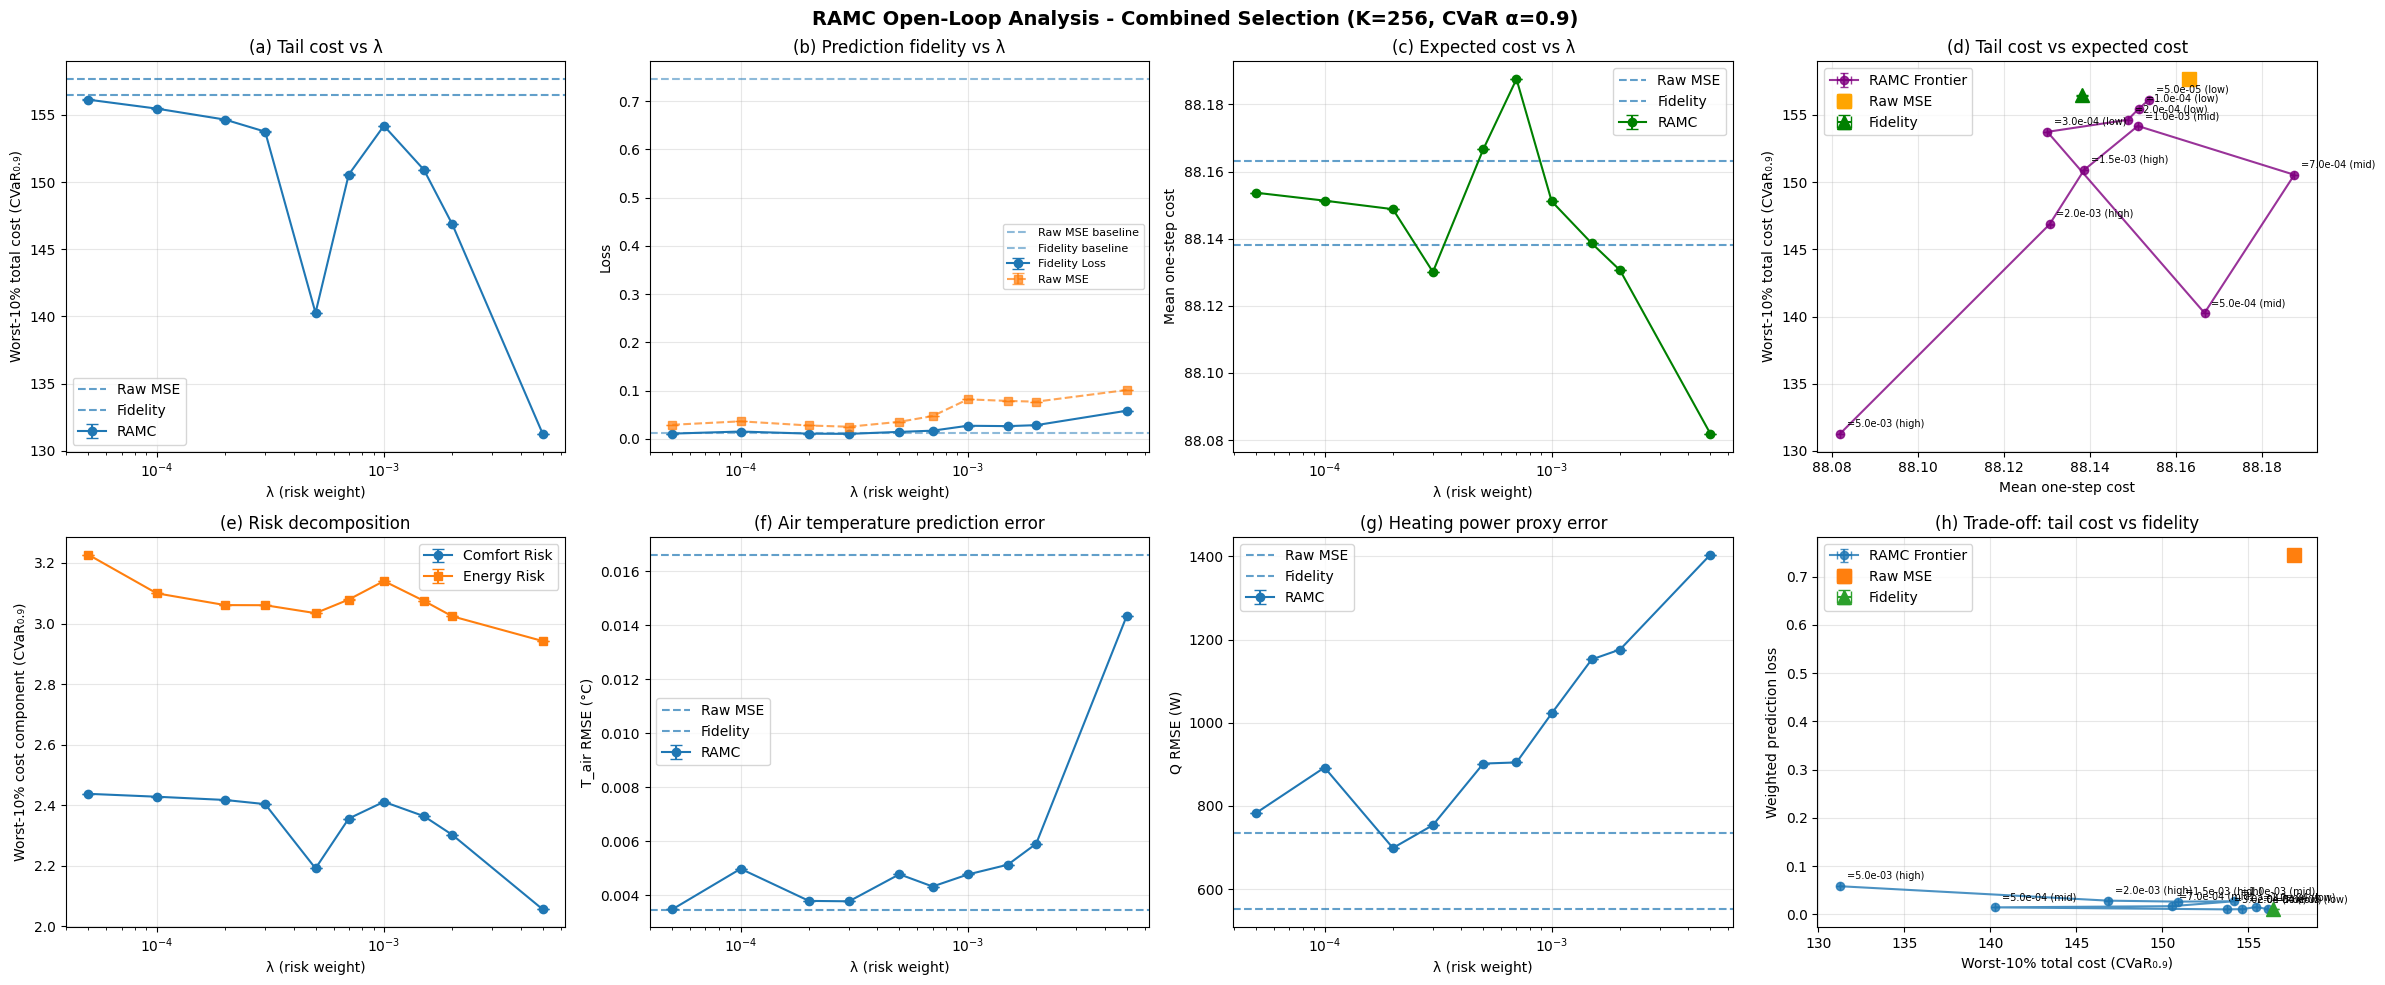

Trade-off plot saved: results/RAMC_FULL_cvar_20260518_182822/ramc_tradeoff_VAL.png
Analyzing per-state fidelity...


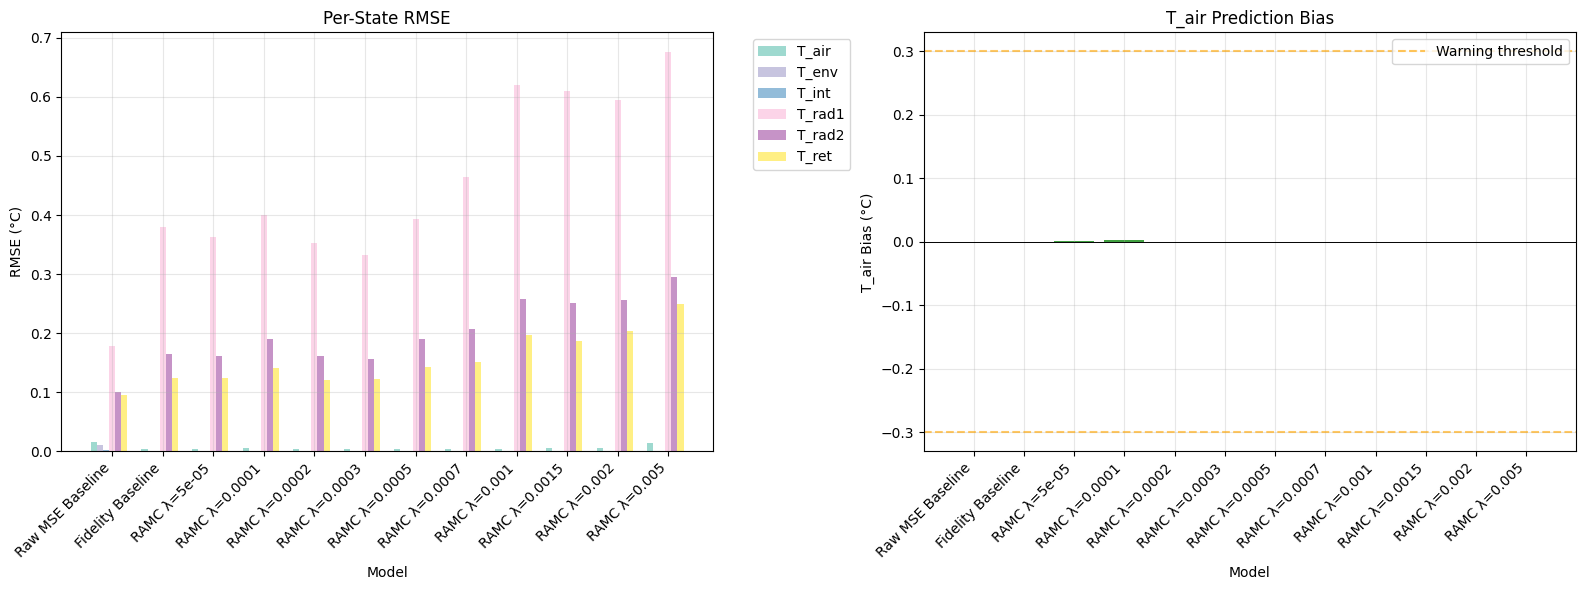

  Table IV (per-state RMSE) saved: results/RAMC_FULL_cvar_20260518_182822/table_IV_per_state_rmse_VAL.csv

TEST SET ANALYSIS
----------------------------------------------------------------------
Analyzing trade-off (selection_policy=combined)

DETAILED RESULTS TABLE (COMBINED SELECTION)
Model                  λ        mse_raw            fidelity           risk               risk_comfort       risk_energy        Q_rmse        
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Raw MSE Baseline       0.0000   0.00609±0.00000   0.68509±0.00000   156.66054±0.03673   2.44798±0.00058   2.93701±0.00022   442.33±0.00
Fidelity Baseline      0.0000   0.02202±0.00000   0.00825±0.00000   155.36765±0.03659   2.42882±0.00058   2.94166±0.00065   600.67±0.00
RAMC lambda=5e-05      0.0001   0.02017±0.00000   0.00778±0.00000   155.04726±0.03657   2.42374±0.00058   3.02067±0.

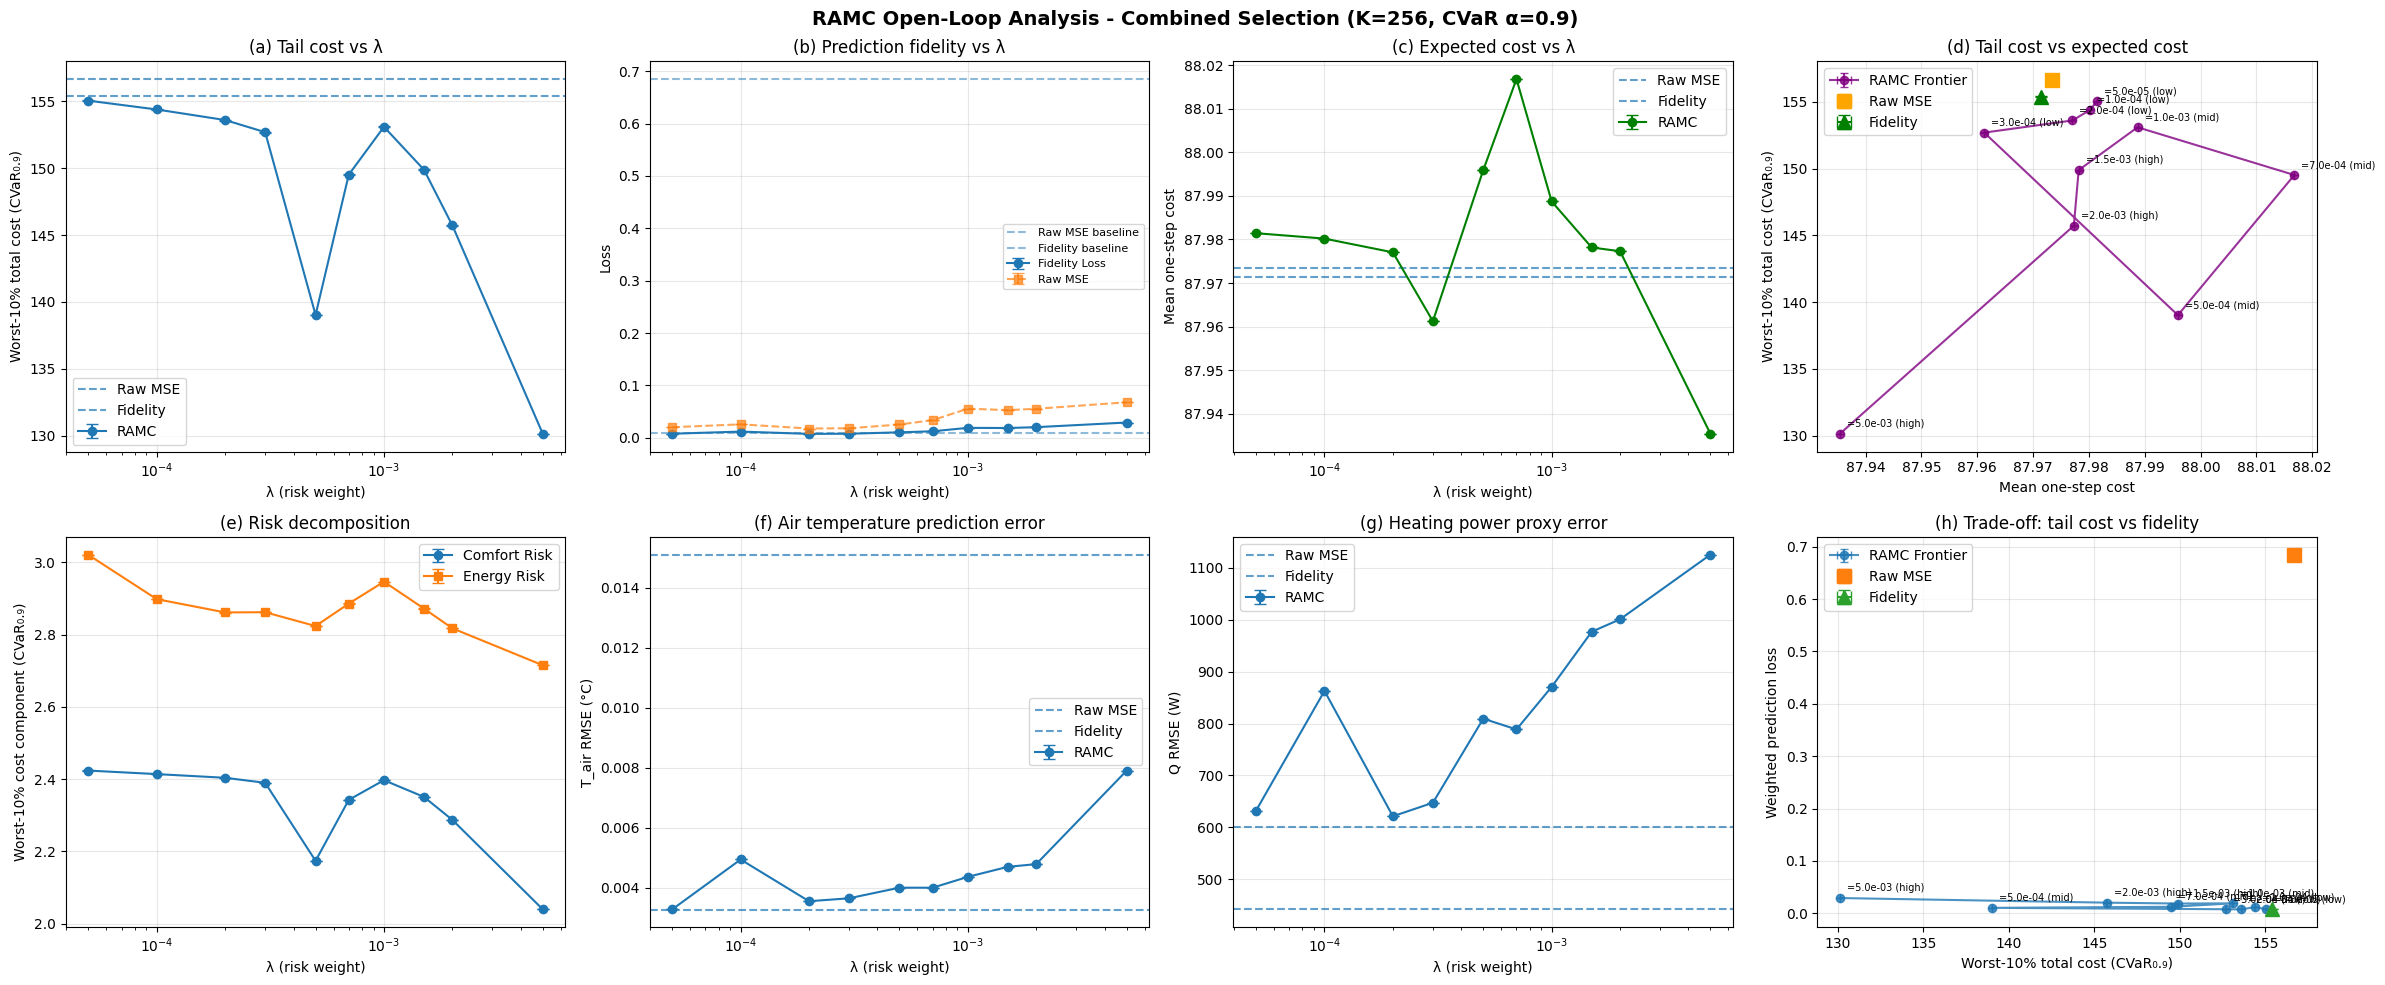

Trade-off plot saved: results/RAMC_FULL_cvar_20260518_182822/ramc_tradeoff_TEST.png
Analyzing per-state fidelity...


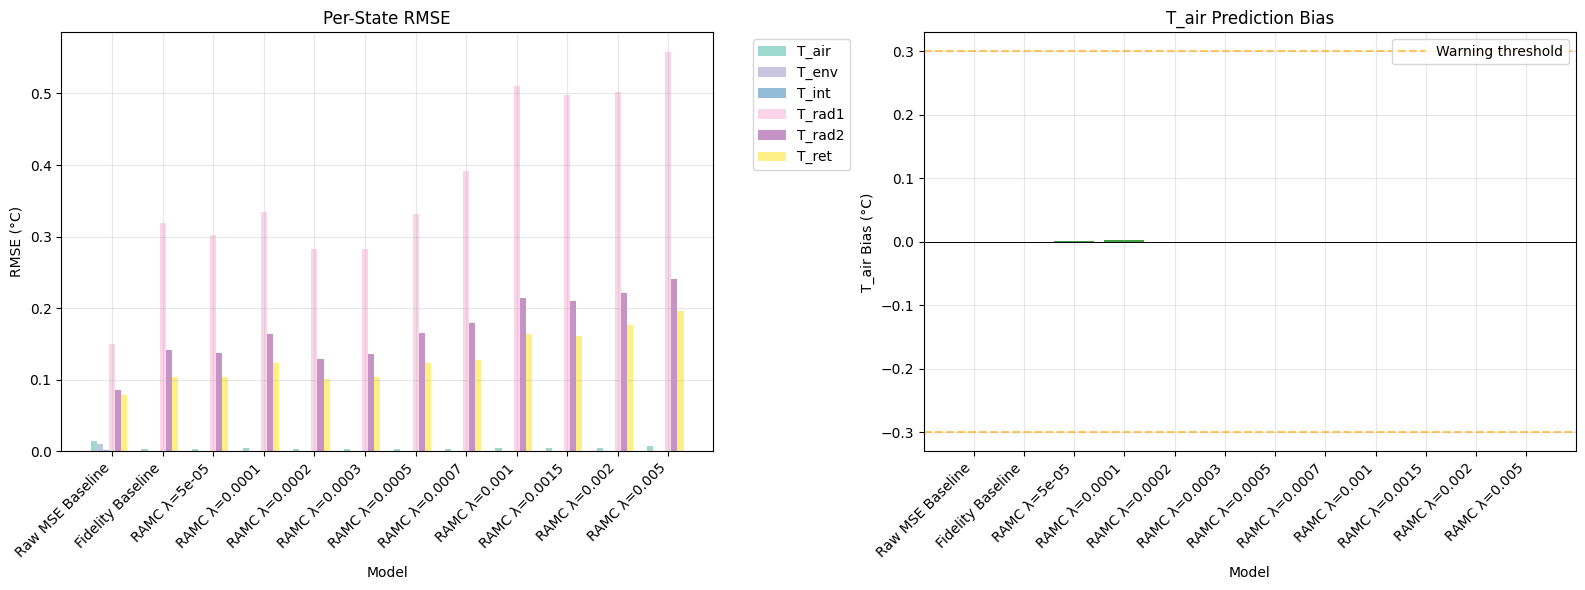

  Table IV (per-state RMSE) saved: results/RAMC_FULL_cvar_20260518_182822/table_IV_per_state_rmse_TEST.csv
Analyzing Pareto frontier...
Analyzing trade-off (selection_policy=combined)

DETAILED RESULTS TABLE (COMBINED SELECTION)
Model                  λ        mse_raw            fidelity           risk               risk_comfort       risk_energy        Q_rmse        
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Raw MSE Baseline       0.0000   0.00609±0.00000   0.68509±0.00000   156.66054±0.03673   2.44798±0.00058   2.93701±0.00022   442.33±0.00
Fidelity Baseline      0.0000   0.02202±0.00000   0.00825±0.00000   155.36765±0.03659   2.42882±0.00058   2.94166±0.00065   600.67±0.00
RAMC lambda=5e-05      0.0001   0.02017±0.00000   0.00778±0.00000   155.04726±0.03657   2.42374±0.00058   3.02067±0.00076   632.50±0.00
RAMC lambda=0.0001     0.0001   0.02571±

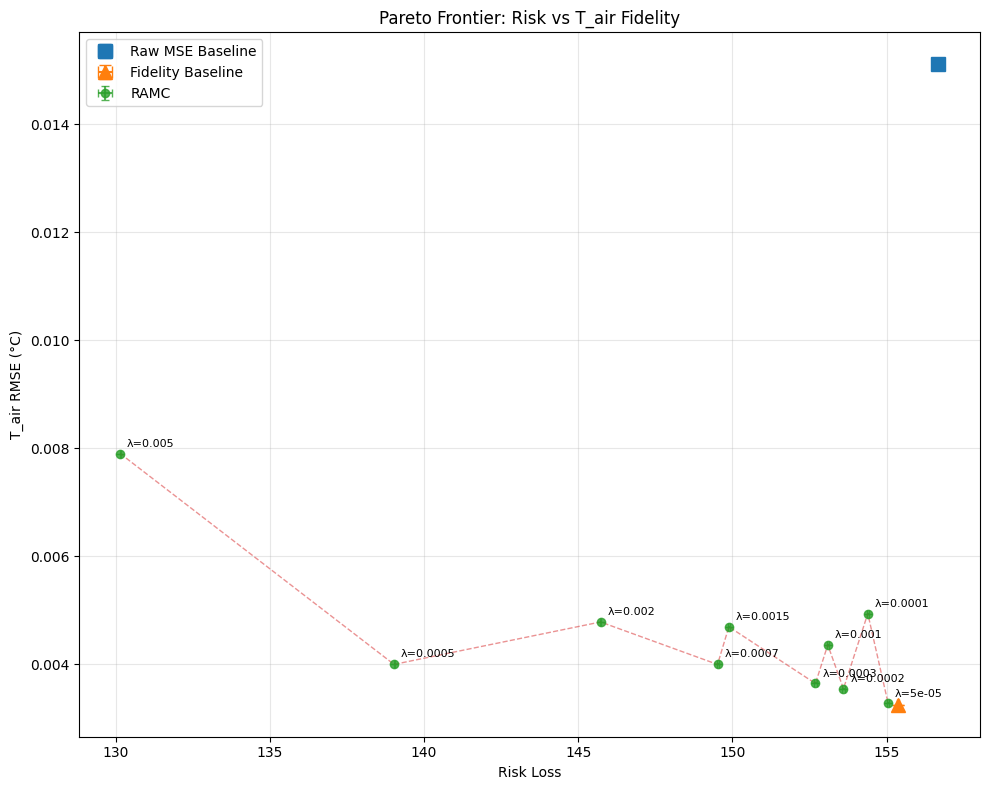


GENERATING METHODS SUMMARY FOR PAPER
----------------------------------------------------------------------
  Methods summary saved: results/RAMC_FULL_cvar_20260518_182822/paper_methods_summary.txt

Results saved to: results/RAMC_FULL_cvar_20260518_182822

STEP 6: GENERATING FINAL REPORT
----------------------------------------------------------------------
Final report saved: results/RAMC_FULL_cvar_20260518_182822/RAMC_Experiment_Report.txt

RAMC FULL EXPERIMENT COMPLETED SUCCESSFULLY

All results available in: results/RAMC_FULL_cvar_20260518_182822

Key output files for paper:
  - ramc_tradeoff_VAL.png / ramc_tradeoff_TEST.png  (Fig. 5)
  - table_IV_per_state_rmse_VAL.csv                 (Table IV)
  - table_V_bias.csv                                (Table V)
  - paper_methods_summary.txt                       (Methods section reference)
  - ramc_pareto_frontier_TEST.png                   (Pareto analysis)

TOTAL TRAINING TIME: 6.1 h  (368 min)


In [4]:
# ============================================================
# Cell 3: Main Training Run
#   Runs main_experiment.py in-process so all variables (RESULTS_DIR
#   etc.) remain accessible in subsequent cells.
#   Expected runtime: T4 ~4-6 h | A100 ~1.5-2.5 h | V100 ~3-4 h
# ============================================================
import time
import runpy

print("Starting main_experiment.py …")
start_time = time.time()

# runpy.run_path executes the script under __main__ so the
#   `if __name__ == "__main__": main()` guard triggers correctly.
runpy.run_path("main_experiment.py", run_name="__main__")

elapsed = time.time() - start_time
print(f"\n{'='*80}")
print(f"TOTAL TRAINING TIME: {elapsed/3600:.1f} h  ({elapsed/60:.0f} min)")
print(f"{'='*80}")


In [5]:
# ============================================================
# Cell 4: Decomposed Evaluation Table
#   Automatically finds the most recent results directory so no
#   manual path edits are needed between runs.
# ============================================================
import glob
import os
import torch
from main_experiment import LOSS_CONFIG
CSV_PATH = "RAMC_training_data_N3.csv"

def _latest_nonempty_results():
    candidates = sorted(glob.glob("results/RAMC_*"))
    # Keep only directories that actually contain checkpoint files
    candidates = [
        d for d in candidates
        if os.path.isdir(d)
        and any(f.endswith(".pth") for f in os.listdir(d))
    ]
    return candidates[-1] if candidates else None

latest_results = _latest_nonempty_results()
if latest_results is None:
    print("No results directory with checkpoints found")
else:
    print(f"Results directory : {latest_results}")

if latest_results:
    import Decompose_evaluation as de

    # Override paths to point at this run's output
    de.RESULTS_DIR  = latest_results
    de.CSV_DATA_PATH = CSV_PATH

    # Align perturbation config with training settings
    de.EVAL_LOSS_CONFIG["sigma_Q_internal"]      = LOSS_CONFIG["sigma_Q_internal"]
    de.EVAL_LOSS_CONFIG["num_perturbations"]      = 256   # higher K for evaluation
    de.EVAL_LOSS_CONFIG["ignore_dataset_bounds"]  = True
    de.EVAL_LOSS_CONFIG["comfort_bounds"]         = LOSS_CONFIG["comfort_bounds"]
    de.EVAL_LOSS_CONFIG["energy_cost_rate"]       = LOSS_CONFIG["energy_cost_rate"]
    de.EVAL_LOSS_CONFIG["w_comfort"]              = LOSS_CONFIG["w_comfort"]
    de.EVAL_LOSS_CONFIG["fidelity_weights"]       = LOSS_CONFIG["fidelity_weights"]

    # Sanity checks before running
    print(f"\nFidelity weights : {de.EVAL_LOSS_CONFIG['fidelity_weights']}")
    print(f"CVaR method      : {de.EVAL_LOSS_CONFIG.get('cvar_method', 'NOT SET')}")

    assert de.EVAL_LOSS_CONFIG.get("cvar_method") == "empirical", (
        "cvar_method in Decompose_evaluation.py must be 'empirical'. "
        "Update that file and re-upload."
    )
    assert de.EVAL_LOSS_CONFIG["fidelity_weights"] == [2.0, 1.0, 1.0, 0.5, 0.5, 2.0], (
        "fidelity_weights in Decompose_evaluation.py must be [2.0, 1.0, 1.0, 0.5, 0.5, 2.0]. "
        "Update that file and re-upload."
    )

    df_results = de.generate_decomposed_evaluation_table(
        results_dir      = latest_results,
        csv_data_path    = CSV_PATH,
        model_config     = de.MODEL_CONFIG,
        eval_loss_config = de.EVAL_LOSS_CONFIG,
        data_config      = de.DATA_CONFIG,
        device           = "cuda" if torch.cuda.is_available() else "cpu",
        num_seeds        = 5,
        enable_tail_diagnostics = False,
        tail_file_tag    = "DIAGNOSTIC",
    )
    print("\nDecomposed evaluation complete")
else:
    print("Skipping decomposed evaluation — no results directory.")


Results directory : results/RAMC_FULL_cvar_20260518_182822

Fidelity weights : [2.0, 1.0, 1.0, 0.5, 0.5, 2.0]
CVaR method      : empirical
RAMC DECOMPOSED EVALUATION TABLE GENERATOR v2.2
Results directory: results/RAMC_FULL_cvar_20260518_182822
Data file: RAMC_training_data_N3.csv
Device: cuda
Evaluation K: 256
Number of seeds: 5
Tail diagnostics: DISABLED

Step 1: Loading data...
Loading data from: RAMC_training_data_N3.csv
  Timestamp column detected - preserving original row order
  Using existing episode_id column: 300 episodes
  Found 'Tmin' and 'Tmax' columns
Dataset loaded:
  Samples: 302400
  States: torch.Size([302400, 6])
  Controls: torch.Size([302400, 2])
  Disturbances: torch.Size([302400, 3])
  Targets: torch.Size([302400, 6])

Data Summary:
  T_air_k: [13.7, 26.1] C
  T_env_k: [5.6, 23.2] C
  T_int_k: [13.8, 23.3] C
  T_rad1_k: [13.9, 58.4] C
  T_rad2_k: [13.8, 57.0] C
  T_ret_k: [13.8, 55.6] C
  T_supply_k: [31.6, 60.0] C
  mdot_k: [0.000, 4.050] kg/s
  T_out_k: [-26.0,

In [7]:
# ============================================================
# Cell 5: Pooled Tail-ECDF Analysis
#   Auto-detects every model checkpoint in the results directory.
#   No lambda values are hardcoded — the model list is built
#   entirely from whatever *.pth files are present.
# ============================================================
import math
if latest_results:
    import pooled_ecdf_analysis as ecdf

    # Override paths
    ecdf.RESULTS_DIR  = latest_results
    ecdf.CSV_DATA_PATH = CSV_PATH
    ecdf.OUTPUT_DIR   = latest_results
    ecdf.COST_CONFIG["energy_cost_rate"] = LOSS_CONFIG["energy_cost_rate"]
    ecdf.COST_CONFIG["w_comfort"]        = LOSS_CONFIG["w_comfort"]

    # ── Auto-detect all checkpoint stems ─────────────────────
    pth_stems = sorted(
        f.replace("_best.pth", "")
        for f in os.listdir(latest_results)
        if f.endswith("_best.pth")
    )
    print("Available model checkpoints:")
    for s in pth_stems:
        print(f"  {s}")

    # ── Assign stable display labels ─────────────────────────
    # Label logic: Raw MSE -> fixed label; Fidelity -> fixed label;
    # RAMC -> "RAMC (λ=X)" derived from the checkpoint stem so it
    # is always correct regardless of which lambdas were trained.
    def _stem_to_label(stem: str) -> str:
        if stem.startswith("Raw_MSE"):
            return "Raw MSE"
        if stem.startswith("Fidelity"):
            return "Fidelity (λ=0)"
        # RAMC stems look like: RAMC_lambda_0.001_op_cvar[_rollout_a1.0]
        import re as _re
        m = _re.search(r"RAMC_lambda_([\d.e+-]+)", stem)
        if m:
            lam = float(m.group(1))
            # Format as clean scientific notation
            if lam == 0:
                return "RAMC (λ=0)"

            exp   = int(math.floor(math.log10(lam)))
            coeff = lam / (10 ** exp)

            if abs(coeff - round(coeff)) < 1e-9:
                coeff = int(round(coeff))
                return f"RAMC (λ={coeff}×10^{exp})" if coeff != 1 else f"RAMC (λ=10^{exp})"
            return f"RAMC (λ={lam:.2g})"
        return stem   # fallback: use stem as-is

    models = [(stem, _stem_to_label(stem)) for stem in pth_stems]

    # ── Auto-generate plot styles ─────────────────────────────
    # Fixed palette: Raw MSE = red, Fidelity = blue (dashed),
    # RAMC variants cycle through greens / purples / oranges.
    RAMC_COLORS = [
        "#2ca02c",  # green
        "#9467bd",  # purple
        "#ff7f0e",  # orange
        "#17becf",  # teal
        "#bcbd22",  # yellow-green
        "#8c564b",  # brown
        "#e377c2",  # pink
    ]
    ramc_color_iter = iter(RAMC_COLORS)

    styles = {}
    for stem, label in models:
        if label == "Raw MSE":
            styles[label] = {"color": "#d62728", "linestyle": "-",  "linewidth": 2.5, "alpha": 0.7}
        elif label.startswith("Fidelity"):
            styles[label] = {"color": "#1f77b4", "linestyle": "--", "linewidth": 2.0, "alpha": 0.9}
        else:
            color = next(ramc_color_iter, "#7f7f7f")
            styles[label] = {"color": color, "linestyle": "-", "linewidth": 2.0, "alpha": 1.0}

    ecdf.MODELS_TO_COMPARE = models
    ecdf.PLOT_STYLES       = styles

    print(f"\nComparing {len(models)} models:")
    for stem, label in models:
        print(f"  {label:<35s}  <- {stem}")

    ecdf.main()
    print("\nPooled ECDF analysis complete")
else:
    print("Skipping ECDF analysis — no results directory.")

Available model checkpoints:
  Fidelity_Baseline_rollout_a1.0
  MeanCost_lambda_0.0015_rollout_a1.0
  PertOnly_gamma_0.0015_rollout_a1.0
  RAMC_lambda_0.0001_op_cvar_rollout_a1.0
  RAMC_lambda_0.0002_op_cvar_rollout_a1.0
  RAMC_lambda_0.0003_op_cvar_rollout_a1.0
  RAMC_lambda_0.0005_op_cvar_rollout_a1.0
  RAMC_lambda_0.0007_op_cvar_rollout_a1.0
  RAMC_lambda_0.0015_op_cvar_rollout_a1.0
  RAMC_lambda_0.001_op_cvar_rollout_a1.0
  RAMC_lambda_0.002_op_cvar_rollout_a1.0
  RAMC_lambda_0.005_op_cvar_rollout_a1.0
  RAMC_lambda_5e-05_op_cvar_rollout_a1.0
  Raw_MSE_Baseline

Comparing 14 models:
  Fidelity (λ=0)                       <- Fidelity_Baseline_rollout_a1.0
  MeanCost_lambda_0.0015_rollout_a1.0  <- MeanCost_lambda_0.0015_rollout_a1.0
  PertOnly_gamma_0.0015_rollout_a1.0   <- PertOnly_gamma_0.0015_rollout_a1.0
  RAMC (λ=10^-4)                       <- RAMC_lambda_0.0001_op_cvar_rollout_a1.0
  RAMC (λ=2×10^-4)                     <- RAMC_lambda_0.0002_op_cvar_rollout_a1.0
  RAMC (λ=3×10

In [8]:
# ============================================================
# Cell 6: Final Summary
#   Lists every file produced in the results directory with its
#   size.  No hardcoded model names or lambda values.
# ============================================================
print("=" * 80)
print("RAMC TRAINING PIPELINE COMPLETE")
print("=" * 80)

if latest_results:
    print(f"\nAll outputs in: {latest_results}\n")

    all_files = sorted(os.listdir(latest_results))
    for f in all_files:
        fp = os.path.join(latest_results, f)
        size_kb = os.path.getsize(fp) / 1024
        print(f"  {f:<55s} {size_kb:>8.1f} KB")

    print(f"\n{'─'*80}")
    print("KEY FILE TYPES:")
    print(f"{'─'*80}")
    csvs  = [f for f in all_files if f.endswith(".csv")]
    pngs  = [f for f in all_files if f.endswith(".png")]
    jsons = [f for f in all_files if f.endswith(".json")]
    txts  = [f for f in all_files if f.endswith(".txt")]
    pths  = [f for f in all_files if f.endswith(".pth")]

    if csvs:
        print(f"\nTables / CSVs ({len(csvs)}):")
        for f in csvs:
            print(f"  {f}")
    if pngs:
        print(f"\nFigures / PNGs ({len(pngs)}):")
        for f in pngs:
            print(f"  {f}")
    if jsons:
        print(f"\nJSON metrics ({len(jsons)}):")
        for f in jsons:
            print(f"  {f}")
    if txts:
        print(f"\nText reports ({len(txts)}):")
        for f in txts:
            print(f"  {f}")
    if pths:
        print(f"\nModel checkpoints ({len(pths)}):")
        for f in pths:
            print(f"  {f}")
else:
    print("No results directory found.")

RAMC TRAINING PIPELINE COMPLETE

All outputs in: results/RAMC_FULL_cvar_20260518_182822

  Fidelity_Baseline_rollout_a1.0_best.pth                   1274.1 KB
  Fidelity_Baseline_rollout_a1.0_best_cost.pth              1238.8 KB
  Fidelity_Baseline_rollout_a1.0_best_risk.pth              1237.9 KB
  MeanCost_lambda_0.0015_rollout_a1.0_best.pth              1274.2 KB
  MeanCost_lambda_0.0015_rollout_a1.0_best_cost.pth         1242.5 KB
  MeanCost_lambda_0.0015_rollout_a1.0_best_risk.pth         1275.1 KB
  PertOnly_gamma_0.0015_rollout_a1.0_best.pth               1274.7 KB
  PertOnly_gamma_0.0015_rollout_a1.0_best_cost.pth          1247.9 KB
  PertOnly_gamma_0.0015_rollout_a1.0_best_risk.pth          1274.9 KB
  RAMC_Experiment_Report.txt                                   1.5 KB
  RAMC_lambda_0.0001_op_cvar_rollout_a1.0_best.pth          1274.2 KB
  RAMC_lambda_0.0001_op_cvar_rollout_a1.0_best_cost.pth     1259.5 KB
  RAMC_lambda_0.0001_op_cvar_rollout_a1.0_best_risk.pth     1273.9 KB
 